# Análisis de Sentimientos en Percy Jackson

Este notebook analiza el sentimiento de las oraciones en el libro "The Lightning Thief" de Rick Riordan usando técnicas de NLP.

### Universidad Icesi

Maestria en IA Aplicada

Catedra: **Procesamiento de Lenguaje Natural**

Grupo: **Golf**
Realizado por:
- **Arlex Pino**
- **Alfredo Aponte**

----
## 1. Configuración Inicial

Verificamos si estamos en Google Colab para descargar dependencias si es necesario.

In [1]:
import sys
import warnings

warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules

In [2]:
if IN_COLAB:
    !wget https://github.com/Ohtar10/icesi-nlp/raw/refs/heads/main/requirements.txt
    %pip install -r requirements.txt

In [3]:
if IN_COLAB:
    !wget https://github.com/Ohtar10/icesi-nlp/raw/refs/heads/main/Sesion1/percy_jackson_book_1.txt

---
## 2. Cargar spaCy

Cargamos el modelo de inglés `en_core_web_sm` que incluye:
- Tokenizador
- Part-of-Speech (POS) tagger
- Dependency parser
- Named Entity Recognizer (NER)

In [4]:
# RUN THIS CELL to perform standard imports:
import spacy
nlp = spacy.load('en_core_web_sm')

---
## 3. Descargar Dataset

Descargamos los libros de Percy Jackson desde Kaggle y copiamos los archivos a la carpeta actual para facilitar su acceso.

In [5]:
import kagglehub

try:
    print("✓ kagglehub ya está instalado")
except ImportError:
    print("Instalando kagglehub...")
    !pip install kagglehub
    print("✓ kagglehub ha sido instalado correctamente")

✓ kagglehub ya está instalado


In [6]:
import os
import shutil

# Download latest version
path = kagglehub.dataset_download("shobhit043/percy-jackson-first-5-books")

print("Path to dataset files:", path)
print("Files downloaded:", os.listdir(path))

# Copy files to current directory
for file in os.listdir(path):
    src = os.path.join(path, file)
    dst = os.path.join(".", file)
    if os.path.isfile(src):
        shutil.copy(src, dst)
    elif os.path.isdir(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)

print("Files in current directory:", os.listdir('.'))

Path to dataset files: C:\Users\apont\.cache\kagglehub\datasets\shobhit043\percy-jackson-first-5-books\versions\1
Files downloaded: ['percy_jackson_book_1.txt', 'percy_jackson_book_2.txt', 'percy_jackson_book_3.txt', 'percy_jackson_book_4.txt', 'percy_jackson_book_5.txt']
Files in current directory: ['01. El caballero de la armadura oxidada - Robert Fisher.pdf', '02-26-GQ.pdf', '03-26-Arquitectura y Diseno (1).pdf', '03-26-Arquitectura y Diseno.pdf', '15_Diccionario_de_Datos-_SECOP_II_-_Contratos_Electr_nicos.docx', '2025-03-19 Meeting Transcription.pdf', '2025-05-16 Meeting Transcription.pdf', '2025-05-23 Meeting Transcription.pdf', '2025-06-16 Proyecto II de innovacinnn tecnolnngica en IA.pdf', '2025-06-27 Meeting Transcription.pdf', '20250503 Arboleda Colpatria.pdf', '20250503 Arboleda.PDF', '20250503 Ford BBVA.pdf', '20250503 Ford Sufi.pdf', '20250503 Ford Wompi.pdf', '20250509 Predial Blue Park SDHB.pdf', '20250509 Predial Zento 75 1102.pdf', '20250703 Predial Blue 23 - Apto.pdf',

---
## 4. Procesar el Documento

Leemos el primer libro de Percy Jackson y lo procesamos con spaCy. El objeto `doc` contiene:
- Tokens individuales
- Información gramatical (POS tags, dependencias)
- Entidades nombradas
- Estructura de oraciones

In [7]:
# Leer el archivo y procesarlo con spaCy
with open('./percy_jackson_book_1.txt', encoding='utf-8') as file:
    doc = nlp(file.read())

print(f"Documento procesado: {len(doc)} tokens")

Documento procesado: 127898 tokens


### 4.1. Vista Previa del Documento

Mostramos los primeros 50 tokens para verificar que el documento se cargó correctamente.

In [8]:
# Primeros 50 tokens del documento
doc[:50]



BOOKS BY RICK RIORDAN

PERCY JACKSON AND THE OLYMPIANS
The Lightning Thief
The Sea of Monsters
The Titan’s Curse
The Battle of the Labyrinth
The Last Olympian
The Demigod Files
Percy Jackson’s Greek Gods, illustrated by John Rocco

### 4.2. Estadísticas Generales y Riqueza del Vocabulario

Analizamos características cuantitativas del texto para entender el estilo del autor:
- **Type-Token Ratio (TTR)**: mide la riqueza del vocabulario (más alto = más variado)
- **Densidad léxica**: proporción de palabras con contenido semántico
- **Longitud promedio de oración**: indica complejidad narrativa

In [9]:
# =============================================
# ESTADÍSTICAS GENERALES DEL TEXTO
# is_alpha  → solo letras (sin puntuación ni números)
# is_stop   → palabras vacías (the, a, is...)
# is_punct  → puntuación
# =============================================

# Tokens básicos
total_tokens = len(doc)
tokens_alpha = [t for t in doc if t.is_alpha]
tokens_sin_stopwords = [t for t in tokens_alpha if not t.is_stop]
palabras_unicas = set(t.lemma_.lower() for t in tokens_alpha)

# Oraciones
total_oraciones = len(list(doc.sents))
longitudes_oraciones = [len([t for t in s if t.is_alpha]) for s in doc.sents]
promedio_oracion = sum(longitudes_oraciones) / len(longitudes_oraciones)

# Métricas de vocabulario
ttr = len(palabras_unicas) / len(tokens_alpha) * 100  # Type-Token Ratio
densidad_lexica = len(tokens_sin_stopwords) / len(tokens_alpha) * 100

print("=" * 60)
print("   ESTADÍSTICAS DEL LIBRO 1 - PERCY JACKSON")
print("=" * 60)
print(f"\n  Tokens totales:             {total_tokens:>10,}")
print(f"  - Palabras (solo letras):   {len(tokens_alpha):>10,}")
print(f"  - Vocabulario único:        {len(palabras_unicas):>10,}")
print(f"  - Total de oraciones:       {total_oraciones:>10,}")
print(f"\n  MÉTRICAS DE ESTILO:")
print(f"  - Type-Token Ratio (TTR):      {ttr:>9.2f}%")
print(f"  - Densidad léxica:             {densidad_lexica:>9.2f}%")
print(f"  - Longitud promedio oración:    {promedio_oracion:>9.1f} palabras")
print("=" * 60) 

   ESTADÍSTICAS DEL LIBRO 1 - PERCY JACKSON

  Tokens totales:                127,898
  - Palabras (solo letras):       92,026
  - Vocabulario único:             5,764
  - Total de oraciones:            8,946

  MÉTRICAS DE ESTILO:
  - Type-Token Ratio (TTR):           6.26%
  - Densidad léxica:                 44.38%
  - Longitud promedio oración:         10.3 palabras


---
## 5. Análisis de Sentimientos con VADER (NLTK)

En esta sección se utiliza VADER (Valence Aware Dictionary and Sentiment Reasoner), una herramienta incluida en NLTK diseñada específicamente para análisis de sentimientos en texto en inglés. VADER es particularmente útil para textos narrativos porque combina un enfoque basado en léxico con reglas que consideran intensidad, negación y puntuación.

In [10]:
# Instalar VADER de NLTK para análisis de sentimientos
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\apont\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [11]:
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Crear el analizador de sentimientos VADER
sid = SentimentIntensityAnalyzer()

# Extraer oraciones y calcular sentimientos
sentences_data = []

for i, sent in enumerate(doc.sents):
    # Limpiar la oración
    sent_text = sent.text.strip()
    
    # Filtrar oraciones muy cortas o que no sean texto narrativo
    if len(sent_text) < 10 or sent_text.isupper():
        continue
    
    # Calcular sentimiento con VADER
    scores = sid.polarity_scores(sent_text)
    compound = scores['compound']  # Score combinado (-1 a 1)
    
    # Clasificar el sentimiento basado en compound score
    if compound >= 0.05:
        label = 'pos'
    elif compound <= -0.05:
        label = 'neg'
    else:
        label = 'neu'
    
    sentences_data.append({
        'sentence': sent_text,
        'neg': scores['neg'],
        'neu': scores['neu'],
        'pos': scores['pos'],
        'compound': compound,
        'label': label,
        'length': len(sent_text)
    })

# Crear DataFrame
df = pd.DataFrame(sentences_data)
print(f"Total de oraciones analizadas: {len(df)}")
df.head(10)

Total de oraciones analizadas: 8672


,sentence,neg,neu,pos,compound,label,length
0,BOOKS BY RICK RIORDAN\n\nPERCY JACKSON AND THE...,0.218,0.691,0.092,-0.8885,neg,366
1,The Red Pyramid\nThe Throne of Fire\nThe Serpe...,0.117,0.778,0.105,-0.1260,neg,245
2,THE HEROES OF OLYMPUS\nThe Lost Hero\nThe Son ...,0.032,0.843,0.125,0.9265,pos,771
3,All rights reserved.,0.000,1.000,0.000,0.0000,neu,20
4,"Published by Disney • Hyperion Books, an impri...",0.000,1.000,0.000,0.0000,neu,70
5,No\npart of this book may be reproduced or tra...,0.058,0.942,0.000,-0.2960,neg,242
6,For information address Disney • Hyperion Book...,0.000,1.000,0.000,0.0000,neu,95
7,ISBN 978-1-4231-3189-2\nVisit www.disneyhyperi...,0.000,1.000,0.000,0.0000,neu,145
8,I Accidentally Vaporize My Pre-algebra Teacher...,0.324,0.676,0.000,-0.3400,neg,49
9,Three Old Ladies Knit the Socks of Death\n3.,0.328,0.672,0.000,-0.5994,neg,43


In [12]:
# Distribución de sentimientos
print("Distribución de sentimientos:\n")
print(df['label'].value_counts())
print("\n")
print(df['label'].value_counts(normalize=True).mul(100).round(2))

Distribución de sentimientos:

label
neu    4702
neg    1990
pos    1980
Name: count, dtype: int64


label
neu    54.22
neg    22.95
pos    22.83
Name: proportion, dtype: float64


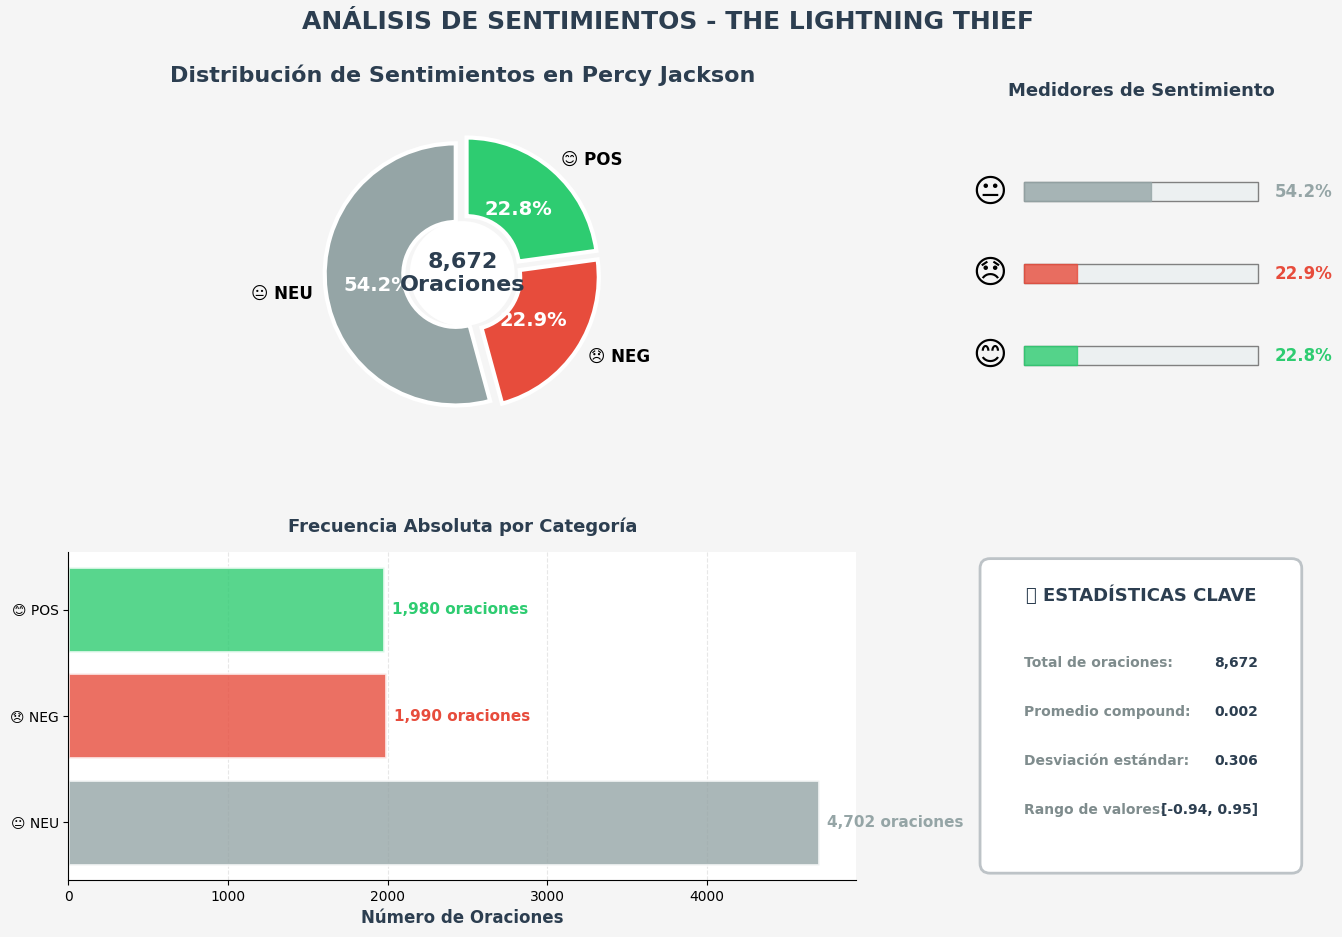


🎯 RESUMEN DEL ANÁLISIS DE SENTIMIENTOS
😊 POS      → 1,980 oraciones (22.83%)
😐 NEU      → 4,702 oraciones (54.22%)
😞 NEG      → 1,990 oraciones (22.95%)
💡 Insight: El libro tiene un tono predominantemente NEU


In [13]:
# Visualización Dashboard de Sentimientos
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, Rectangle, FancyBboxPatch
import matplotlib.patches as mpatches

# Configurar la figura con fondo atractivo
fig = plt.figure(figsize=(16, 10), facecolor='#f5f5f5')
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.35)

# Obtener datos de distribución
sentiment_counts = df['label'].value_counts()
sentiment_pct = df['label'].value_counts(normalize=True) * 100

# Colores vibrantes para cada sentimiento
colors_dict = {'pos': '#2ecc71', 'neu': '#95a5a6', 'neg': '#e74c3c'}
emojis = {'pos': '😊', 'neu': '😐', 'neg': '😞'}

# ============ Panel 1: Gráfico de Donut Mejorado ============
ax1 = fig.add_subplot(gs[0, :2])
wedges, texts, autotexts = ax1.pie(
    sentiment_counts.values,
    labels=[f"{emojis[k]} {k.upper()}" for k in sentiment_counts.index],
    autopct='%1.1f%%',
    colors=[colors_dict[k] for k in sentiment_counts.index],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 3, 'width': 0.6},
    textprops={'fontsize': 12, 'weight': 'bold'},
    explode=(0.05, 0.05, 0.05)
)

# Estilizar los porcentajes
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_weight('bold')

# Agregar círculo central con estadística clave
centre_circle = Circle((0, 0), 0.40, fc='white', linewidth=0)
ax1.add_artist(centre_circle)
ax1.text(0, 0, f'{len(df):,}\nOraciones', ha='center', va='center',
         fontsize=16, weight='bold', color='#2c3e50')

ax1.set_title('Distribución de Sentimientos en Percy Jackson',
              fontsize=16, weight='bold', pad=20, color='#2c3e50')

# ============ Panel 2: Medidores de Sentimiento (Gauges) ============
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')

y_positions = [7.5, 5, 2.5]
for idx, (label, value) in enumerate(sentiment_pct.items()):
    y_pos = y_positions[idx]
    color = colors_dict[label]
    emoji = emojis[label]
    
    # Barra de progreso
    bar_width = value / 100 * 7
    ax2.add_patch(Rectangle((1.5, y_pos - 0.3), 7, 0.6, 
                            facecolor='#ecf0f1', edgecolor='gray', linewidth=1))
    ax2.add_patch(Rectangle((1.5, y_pos - 0.3), bar_width, 0.6,
                            facecolor=color, edgecolor=color, linewidth=1, alpha=0.8))
    
    # Etiquetas
    ax2.text(0.5, y_pos, emoji, fontsize=24, va='center', ha='center')
    ax2.text(9, y_pos, f'{value:.1f}%', fontsize=12, weight='bold',
             va='center', ha='left', color=color)

ax2.set_title('Medidores de Sentimiento', fontsize=13, weight='bold',
              pad=10, color='#2c3e50')

# ============ Panel 3: Gráfico de Barras Horizontal ============
ax3 = fig.add_subplot(gs[1, :2])
bars = ax3.barh(
    [emojis[k] + ' ' + k.upper() for k in sentiment_counts.index],
    sentiment_counts.values,
    color=[colors_dict[k] for k in sentiment_counts.index],
    alpha=0.8,
    edgecolor='white',
    linewidth=2
)

# Agregar valores en las barras
for i, (bar, val, label) in enumerate(zip(bars, sentiment_counts.values, sentiment_counts.index)):
    width = bar.get_width()
    ax3.text(width + 50, bar.get_y() + bar.get_height()/2,
             f'{val:,} oraciones',
             va='center', fontsize=11, weight='bold',
             color=colors_dict[label])

ax3.set_xlabel('Número de Oraciones', fontsize=12, weight='bold', color='#2c3e50')
ax3.set_title('Frecuencia Absoluta por Categoría', fontsize=13, weight='bold',
              color='#2c3e50', pad=15)
ax3.grid(axis='x', alpha=0.3, linestyle='--')
ax3.set_axisbelow(True)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ============ Panel 4: Tarjeta de Estadísticas ============
ax4 = fig.add_subplot(gs[1, 2])
ax4.set_xlim(0, 10)
ax4.set_ylim(0, 10)
ax4.axis('off')

# Fondo de la tarjeta
ax4.add_patch(FancyBboxPatch((0.5, 0.5), 9, 9,
                             boxstyle="round,pad=0.3",
                             facecolor='white',
                             edgecolor='#bdc3c7',
                             linewidth=2))

# Título de la tarjeta
ax4.text(5, 8.5, '📊 ESTADÍSTICAS CLAVE', ha='center',
         fontsize=13, weight='bold', color='#2c3e50')

# Estadísticas
stats_data = [
    ('Total de oraciones', f'{len(df):,}'),
    ('Promedio compound', f'{df["compound"].mean():.3f}'),
    ('Desviación estándar', f'{df["compound"].std():.3f}'),
    ('Rango de valores', f'[{df["compound"].min():.2f}, {df["compound"].max():.2f}]')
]

y_start = 6.5
for i, (label, value) in enumerate(stats_data):
    y_pos = y_start - i * 1.5
    ax4.text(1.5, y_pos, label + ':', fontsize=10, weight='bold',
             color='#7f8c8d', ha='left')
    ax4.text(8.5, y_pos, value, fontsize=10, weight='bold',
             color='#2c3e50', ha='right')

# Título general
fig.suptitle('ANÁLISIS DE SENTIMIENTOS - THE LIGHTNING THIEF',
             fontsize=18, weight='bold', color='#2c3e50', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Resumen textual mejorado
print("\n" + "="*70)
print("🎯 RESUMEN DEL ANÁLISIS DE SENTIMIENTOS")
print("="*70)
for label in ['pos', 'neu', 'neg']:
    if label in sentiment_counts.index:
        emoji = emojis[label]
        count = sentiment_counts[label]
        pct = sentiment_pct[label]
        print(f"{emoji} {label.upper():8} → {count:5,} oraciones ({pct:5.2f}%)")
print("="*70)
print(f"💡 Insight: El libro tiene un tono predominantemente {sentiment_counts.index[0].upper()}")
print("="*70)

### 5.1. Estadísticas de Sentimientos

In [14]:
# Estadísticas por sentimiento
print("Estadísticas de compound score:\n")
print(df.groupby('label')['compound'].describe())

Estadísticas de compound score:

        count      mean       std     min     25%     50%     75%     max
label                                                                    
neg    1990.0 -0.404130  0.202576 -0.9382 -0.5574 -0.3818 -0.2500 -0.0516
neu    4702.0  0.000141  0.003312 -0.0498  0.0000  0.0000  0.0000  0.0387
pos    1980.0  0.412802  0.184021  0.0516  0.2960  0.4019  0.5106  0.9468


### 5.2. Oraciones Más Positivas

In [15]:
# Las 10 oraciones más positivas
print("Top 10 oraciones más positivas:\n")
for i, row in df.nlargest(10, 'compound').iterrows():
    print(f"Compound: {row['compound']:.3f} | Pos: {row['pos']:.3f}")
    print(f"{row['sentence']}\n")

Top 10 oraciones más positivas:

Compound: 0.947 | Pos: 0.416
“Few mortals have ever
done this and survived: Orpheus, who had great music skill; Hercules, who
had great strength; Houdini, who could escape even the depths of Tartarus.

Compound: 0.938 | Pos: 0.301
Thanks also to my cadre of middle-school beta testers: Travis
Stoll, clever and quick as Hermes; C. C. Kellogg, beloved as Athena; Allison
Bauer, clear-eyed as Artemis the Huntress; and Mrs. Margaret Floyd, the
wise and kindly seer of middle-school English.

Compound: 0.930 | Pos: 0.438
To reach his goal, he must first demonstrate great courage by
succeeding as a keeper, finding a new camper and bringing him safely to
Half-Blood Hill.”

Compound: 0.926 | Pos: 0.125
THE HEROES OF OLYMPUS
The Lost Hero
The Son of Neptune
The Mark of Athena
The House of Hades
The Blood of Olympus
The Demigod Diaries
The Lost Hero: The Graphic Novel
The Son of Neptune: The Graphic Novel

SHORT STORIES BY RICK RIORDAN
The Son of Sobek
A Carter Kane

### 5.3. Oraciones Más Negativas

In [16]:
# Las 10 oraciones más negativas
print("Top 10 oraciones más negativas:\n")
for i, row in df.nsmallest(10, 'compound').iterrows():
    print(f"Compound: {row['compound']:.3f} | Neg: {row['neg']:.3f}")
    print(f"{row['sentence']}\n")

Top 10 oraciones más negativas:

Compound: -0.938 | Neg: 0.415
The Lord of the Dead
resembled pictures I’d seen of Adolph Hitler, or Napoleon, or the terrorist
leaders who direct suicide bombers.

Compound: -0.922 | Neg: 0.403
May the Fates forbid that the gods should ever suffer such a doom, or that we
should ever return to the darkness and chaos of the past.

Compound: -0.917 | Neg: 0.373
I saw visions of grape vines choking unbelievers
to death, drunken warriors insane with battle lust, sailors screaming as their
hands turned to flippers, their faces elongating into dolphin snouts.

Compound: -0.912 | Neg: 0.296
I was about to unwrap my sandwich when Nancy Bobofit appeared in
front of me with her ugly friends—I guess she’d gotten tired of stealing from
the tourists—and dumped her half-eaten lunch in Grover’s lap.

Compound: -0.912 | Neg: 0.364
BOY AND MOTHER STILL MISSING AFTER FREAK CAR
ACCIDENT
BY EILEEN SMYTHE

Sally Jackson and son Percy are still missing one week after
their my

### 5.4. Visualización de Sentimientos

Creamos un histograma para ver la distribución de polaridades.

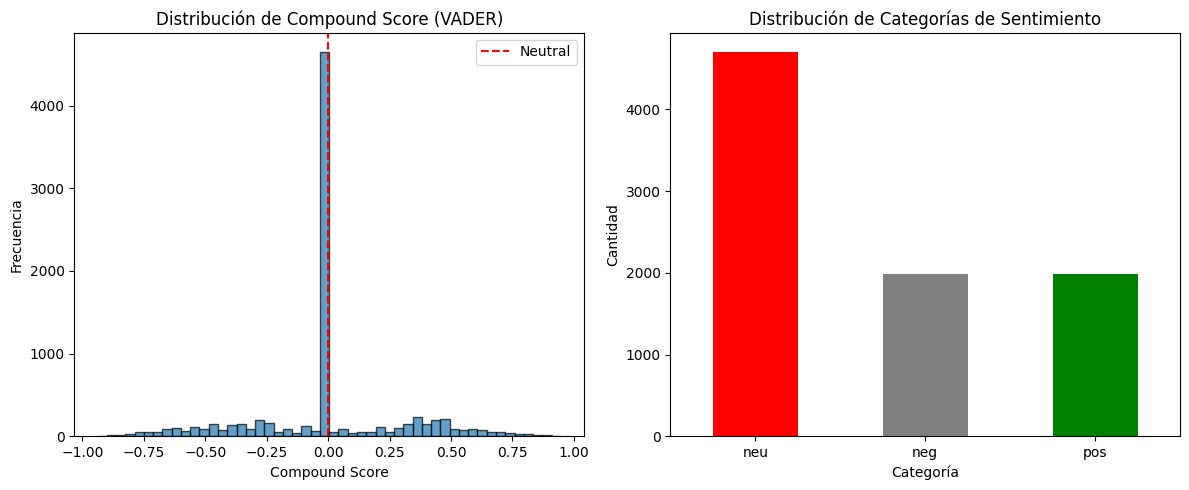

In [17]:
import matplotlib.pyplot as plt

# Histograma de compound score
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['compound'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', label='Neutral')
plt.xlabel('Compound Score')
plt.ylabel('Frecuencia')
plt.title('Distribución de Compound Score (VADER)')
plt.legend()

plt.subplot(1, 2, 2)
df['label'].value_counts().plot(kind='bar', color=['red', 'gray', 'green'])
plt.xlabel('Categoría')
plt.ylabel('Cantidad')
plt.title('Distribución de Categorías de Sentimiento')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 5.5. Análisis Detallado de Scores VADER

VADER proporciona 4 métricas:
- **neg**: proporción de sentimiento negativo
- **neu**: proporción de sentimiento neutral  
- **pos**: proporción de sentimiento positivo
- **compound**: score combinado normalizado entre -1 (muy negativo) y +1 (muy positivo)

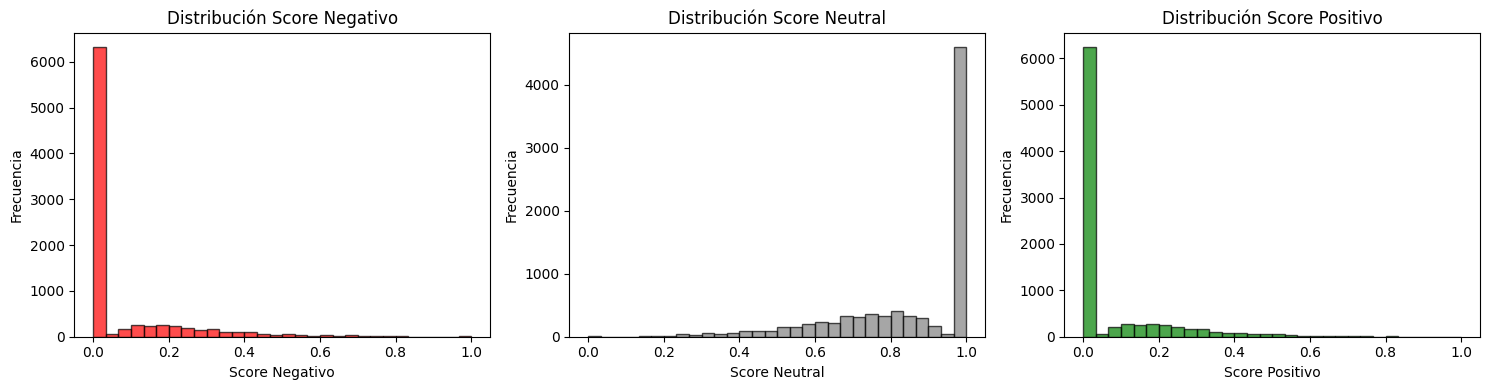

In [18]:
# Distribución de scores individuales
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['neg'], bins=30, color='red', alpha=0.7, edgecolor='black')
axes[0].set_title('Distribución Score Negativo')
axes[0].set_xlabel('Score Negativo')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df['neu'], bins=30, color='gray', alpha=0.7, edgecolor='black')
axes[1].set_title('Distribución Score Neutral')
axes[1].set_xlabel('Score Neutral')
axes[1].set_ylabel('Frecuencia')

axes[2].hist(df['pos'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[2].set_title('Distribución Score Positivo')
axes[2].set_xlabel('Score Positivo')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [19]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Extraer todas las entidades nombradas del documento
entidades = [(ent.text.strip(), ent.label_) for ent in doc.ents if len(ent.text.strip()) > 1]

# Contar las entidades más frecuentes
conteo_entidades = Counter(entidades)

sid = SentimentIntensityAnalyzer()

# Obtener los top 10 personajes más frecuentes
top_personajes = [p for p, _ in Counter(
    {p: c for (p, t), c in conteo_entidades.items() if t == 'PERSON'}
).most_common(10)]

# Calcular sentimiento promedio por personaje
sentimiento_por_personaje = {}
for sent in doc.sents:
    texto_oracion = sent.text.strip()
    if len(texto_oracion) < 10:
        continue
    scores = sid.polarity_scores(texto_oracion)
    for personaje in top_personajes:
        if personaje.lower() in texto_oracion.lower():
            if personaje not in sentimiento_por_personaje:
                sentimiento_por_personaje[personaje] = []
            sentimiento_por_personaje[personaje].append(scores['compound'])

# Crear DataFrame con estadísticas por personaje
datos_personajes = []
for personaje, sentimientos in sentimiento_por_personaje.items():
    datos_personajes.append({
        'personaje': personaje,
        'menciones': len(sentimientos),
        'sentimiento_promedio': np.mean(sentimientos),
        'sentimiento_mediana': np.median(sentimientos),
        'desviacion_std': np.std(sentimientos),
        'pct_positivo': sum(1 for s in sentimientos if s > 0.05) / len(sentimientos) * 100,
        'pct_negativo': sum(1 for s in sentimientos if s < -0.05) / len(sentimientos) * 100,
        'pct_neutro': sum(1 for s in sentimientos if -0.05 <= s <= 0.05) / len(sentimientos) * 100
    })

df_personajes = pd.DataFrame(datos_personajes).sort_values('menciones', ascending=False)
print(df_personajes.to_string(index=False, float_format='%.3f'))


    personaje  menciones  sentimiento_promedio  sentimiento_mediana  desviacion_std  pct_positivo  pct_negativo  pct_neutro
       Grover        459                -0.003                0.000           0.305        22.658        27.669      49.673
     Annabeth        418                 0.022                0.000           0.274        21.531        18.421      60.048
        Percy        258                 0.031                0.000           0.340        29.457        21.705      48.837
         Luke        113                 0.079                0.000           0.318        28.319        16.814      54.867
         Zeus        106                -0.096                0.000           0.369        17.925        34.906      47.170
     Poseidon         89                -0.048                0.000           0.343        23.596        35.955      40.449
        Dodds         61                -0.039                0.000           0.346        22.951        29.508      47.541
      Br

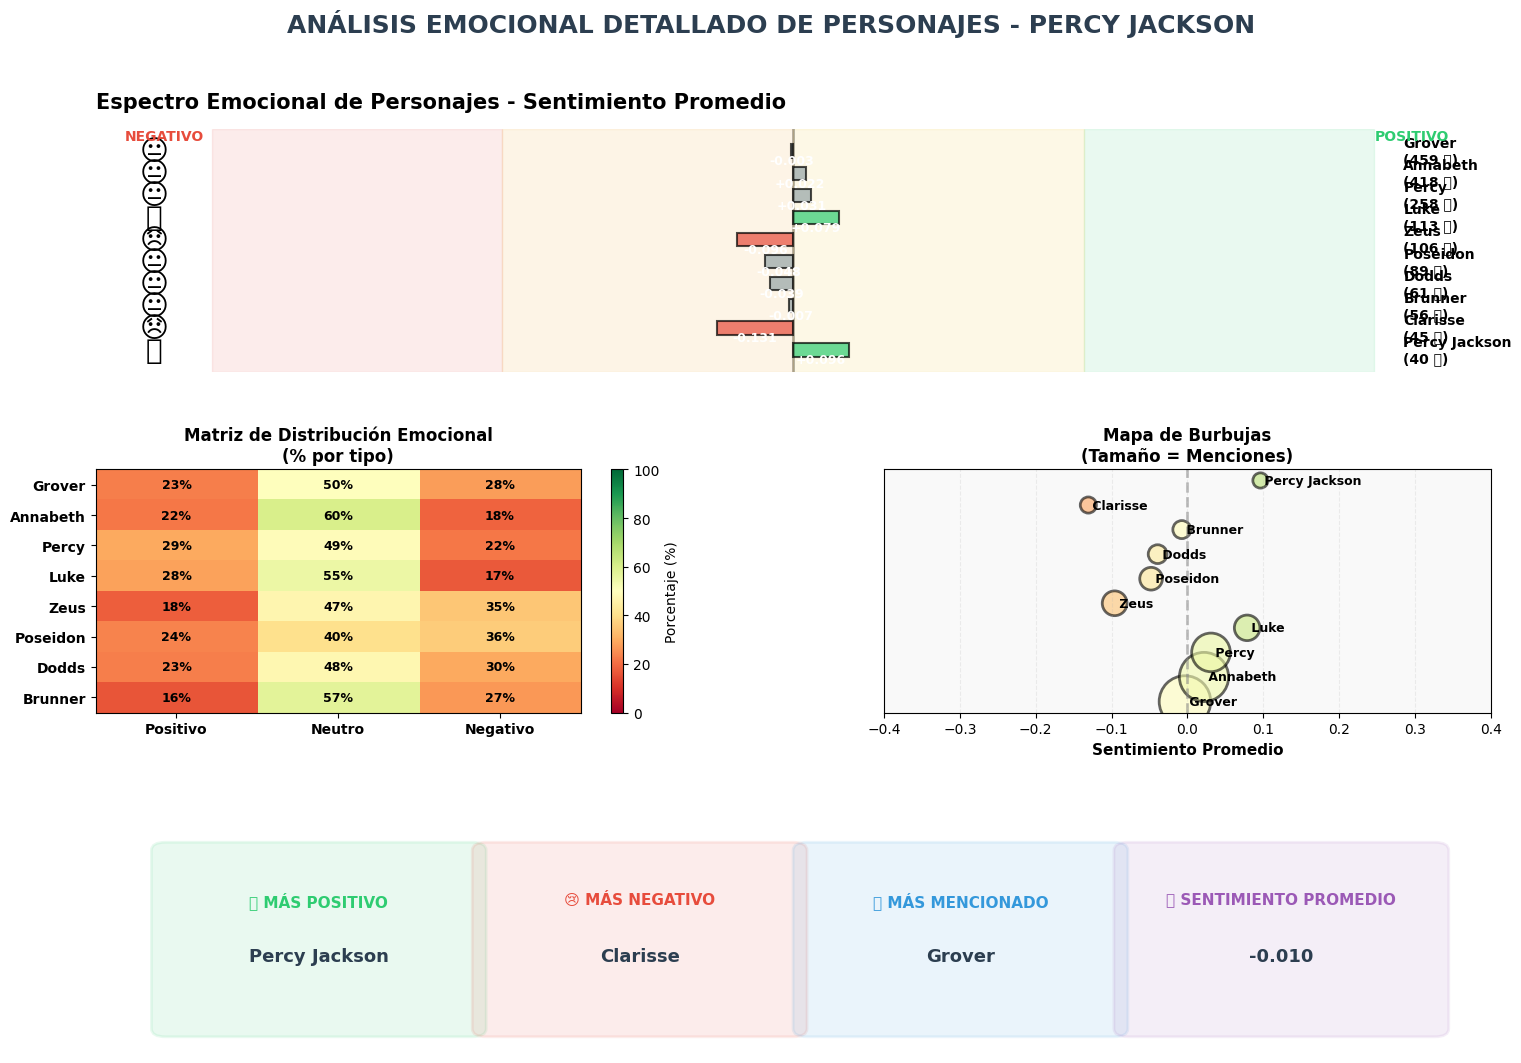


📊 ANÁLISIS CONSOLIDADO DE SENTIMIENTOS POR PERSONAJE

Personaje             Menciones     Sentimiento    % Pos    % Neg
--------------------------------------------------------------------------------
😐 Grover                    459          -0.003    22.7%    27.7%
😐 Annabeth                  418          +0.022    21.5%    18.4%
😐 Percy                     258          +0.031    29.5%    21.7%
😊 Luke                      113          +0.079    28.3%    16.8%
😞 Zeus                      106          -0.096    17.9%    34.9%
😐 Poseidon                   89          -0.048    23.6%    36.0%
😐 Dodds                      61          -0.039    23.0%    29.5%
😐 Brunner                    56          -0.007    16.1%    26.8%
😞 Clarisse                   45          -0.131    13.3%    33.3%
😊 Percy Jackson              40          +0.096    35.0%    20.0%


In [20]:
# Visualización Mapa Emocional de Personajes
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Circle
import numpy as np

fig = plt.figure(figsize=(18, 12), facecolor='white')
gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.3)

# Colores y emojis
emojis_emotional = {
    'muy_positivo': '😄', 'positivo': '🙂', 'neutral': '😐', 
    'negativo': '😞', 'muy_negativo': '😱'
}

# ============ Panel 1: Espectro Emocional Horizontal ============
ax1 = fig.add_subplot(gs[0, :])
ax1.set_xlim(-1.2, 1.2)
ax1.set_ylim(0, len(df_personajes) + 1)
ax1.axis('off')

# Dibujar fondo gradiente
colors_gradient = ['#e74c3c', '#f39c12', '#f1c40f', '#2ecc71']
for i, color in enumerate(colors_gradient):
    ax1.axvspan(-1 + i*0.5, -1 + (i+1)*0.5, alpha=0.1, color=color)

y_offset = len(df_personajes)
for idx, (_, row) in enumerate(df_personajes.iterrows()):
    sentiment = row['sentimiento_promedio']
    name = row['personaje']
    mentions = int(row['menciones'])
    
    # Barra del sentimiento
    color = '#2ecc71' if sentiment > 0.05 else ('#e74c3c' if sentiment < -0.05 else '#95a5a6')
    bar_width = abs(sentiment)
    bar_x = sentiment if sentiment >= 0 else sentiment
    
    ax1.barh(y_offset - idx, bar_width, left=0 if sentiment >= 0 else sentiment,
             color=color, alpha=0.7, height=0.6, edgecolor='black', linewidth=1.5)
    
    # Emoji según sentimiento
    if sentiment > 0.2:
        emoji = emojis_emotional['muy_positivo']
    elif sentiment > 0.05:
        emoji = emojis_emotional['positivo']
    elif sentiment < -0.2:
        emoji = emojis_emotional['muy_negativo']
    elif sentiment < -0.05:
        emoji = emojis_emotional['negativo']
    else:
        emoji = emojis_emotional['neutral']
    
    ax1.text(-1.1, y_offset - idx, emoji, fontsize=20, va='center', ha='center')
    ax1.text(1.05, y_offset - idx, f'{name}\n({mentions} 👤)', 
             fontsize=10, weight='bold', va='center', ha='left')
    ax1.text(sentiment/2, y_offset - idx - 0.15, f'{sentiment:+.3f}', 
             fontsize=9, weight='bold', va='top', ha='center', color='white')

ax1.axvline(x=0, color='black', linewidth=2, linestyle='-', alpha=0.3)
ax1.set_title('Espectro Emocional de Personajes - Sentimiento Promedio', 
              fontsize=15, weight='bold', pad=15, loc='left')
ax1.text(-1.15, len(df_personajes) + 0.5, 'NEGATIVO', fontsize=10, weight='bold', color='#e74c3c')
ax1.text(1, len(df_personajes) + 0.5, 'POSITIVO', fontsize=10, weight='bold', color='#2ecc71')

# ============ Panel 2: Heatmap de Sentimientos ============
ax2 = fig.add_subplot(gs[1, 0])
top_8 = df_personajes.head(8)
sentiment_types = ['pct_positivo', 'pct_neutro', 'pct_negativo']
sentiment_data = top_8[sentiment_types].values

im = ax2.imshow(sentiment_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
ax2.set_xticks(range(3))
ax2.set_xticklabels(['Positivo', 'Neutro', 'Negativo'], fontsize=10, weight='bold')
ax2.set_yticks(range(len(top_8)))
ax2.set_yticklabels(top_8['personaje'].values, fontsize=10, weight='bold')
ax2.set_title('Matriz de Distribución Emocional\n(% por tipo)', fontsize=12, weight='bold')

# Agregar valores en las celdas
for i in range(len(top_8)):
    for j in range(3):
        text = ax2.text(j, i, f'{sentiment_data[i, j]:.0f}%',
                       ha="center", va="center", color="black", fontsize=9, weight='bold')

plt.colorbar(im, ax=ax2, label='Porcentaje (%)')

# ============ Panel 3: Burbujas Interactivas ============
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('#f9f9f9')

mentions = df_personajes['menciones'].values
sentiments = df_personajes['sentimiento_promedio'].values
sizes = mentions * 3

scatter = ax3.scatter(sentiments, range(len(df_personajes)), 
                     s=sizes, c=sentiments, cmap='RdYlGn',
                     alpha=0.6, edgecolors='black', linewidth=2, vmin=-0.3, vmax=0.3)

# Etiquetar personajes
for idx, (name, sent, ment) in enumerate(zip(df_personajes['personaje'], sentiments, mentions)):
    ax3.text(sent, idx, f' {name}', va='center', fontsize=9, weight='bold')

ax3.axvline(x=0, color='gray', linestyle='--', linewidth=2, alpha=0.5)
ax3.set_xlabel('Sentimiento Promedio', fontsize=11, weight='bold')
ax3.set_yticks([])
ax3.set_title('Mapa de Burbujas\n(Tamaño = Menciones)', fontsize=12, weight='bold')
ax3.grid(axis='x', alpha=0.2, linestyle='--')
ax3.set_xlim(-0.4, 0.4)

# ============ Panel 4: Tarjeta de Insights ============
ax4 = fig.add_subplot(gs[2, :])
ax4.set_xlim(0, 10)
ax4.set_ylim(0, 3)
ax4.axis('off')

# Calcular insights
personaje_positivo = df_personajes.loc[df_personajes['sentimiento_promedio'].idxmax(), 'personaje']
personaje_negativo = df_personajes.loc[df_personajes['sentimiento_promedio'].idxmin(), 'personaje']
personaje_frecuente = df_personajes.iloc[0]['personaje']
sent_promedio = df_personajes['sentimiento_promedio'].mean()

insights = [
    (f"🌟 MÁS POSITIVO", personaje_positivo, '#2ecc71'),
    (f"😢 MÁS NEGATIVO", personaje_negativo, '#e74c3c'),
    (f"📢 MÁS MENCIONADO", personaje_frecuente, '#3498db'),
    (f"📊 SENTIMIENTO PROMEDIO", f"{sent_promedio:+.3f}", '#9b59b6')
]

x_positions = [0.5, 2.8, 5.1, 7.4]
for i, (title, value, color) in enumerate(insights):
    x = x_positions[i]
    
    # Cuadro
    ax4.add_patch(FancyBboxPatch((x, 0.3), 2.2, 2.2,
                                  boxstyle="round,pad=0.1",
                                  facecolor=color, alpha=0.1,
                                  edgecolor=color, linewidth=2))
    
    # Texto
    ax4.text(x + 1.1, 2, title, ha='center', va='top',
             fontsize=11, weight='bold', color=color)
    ax4.text(x + 1.1, 1.2, value, ha='center', va='center',
             fontsize=13, weight='bold', color='#2c3e50')

# Título final
fig.suptitle('ANÁLISIS EMOCIONAL DETALLADO DE PERSONAJES - PERCY JACKSON',
             fontsize=18, weight='bold', color='#2c3e50', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Resumen en texto
print("\n" + "="*80)
print("📊 ANÁLISIS CONSOLIDADO DE SENTIMIENTOS POR PERSONAJE")
print("="*80)
print(f"\n{'Personaje':<20} {'Menciones':>10} {'Sentimiento':>15} {'% Pos':>8} {'% Neg':>8}")
print("-"*80)
for _, row in df_personajes.iterrows():
    emoji = '😊' if row['sentimiento_promedio'] > 0.05 else ('😞' if row['sentimiento_promedio'] < -0.05 else '😐')
    print(f"{emoji} {row['personaje']:<18} {int(row['menciones']):>10} {row['sentimiento_promedio']:>+15.3f} {row['pct_positivo']:>7.1f}% {row['pct_negativo']:>7.1f}%")
print("="*80)

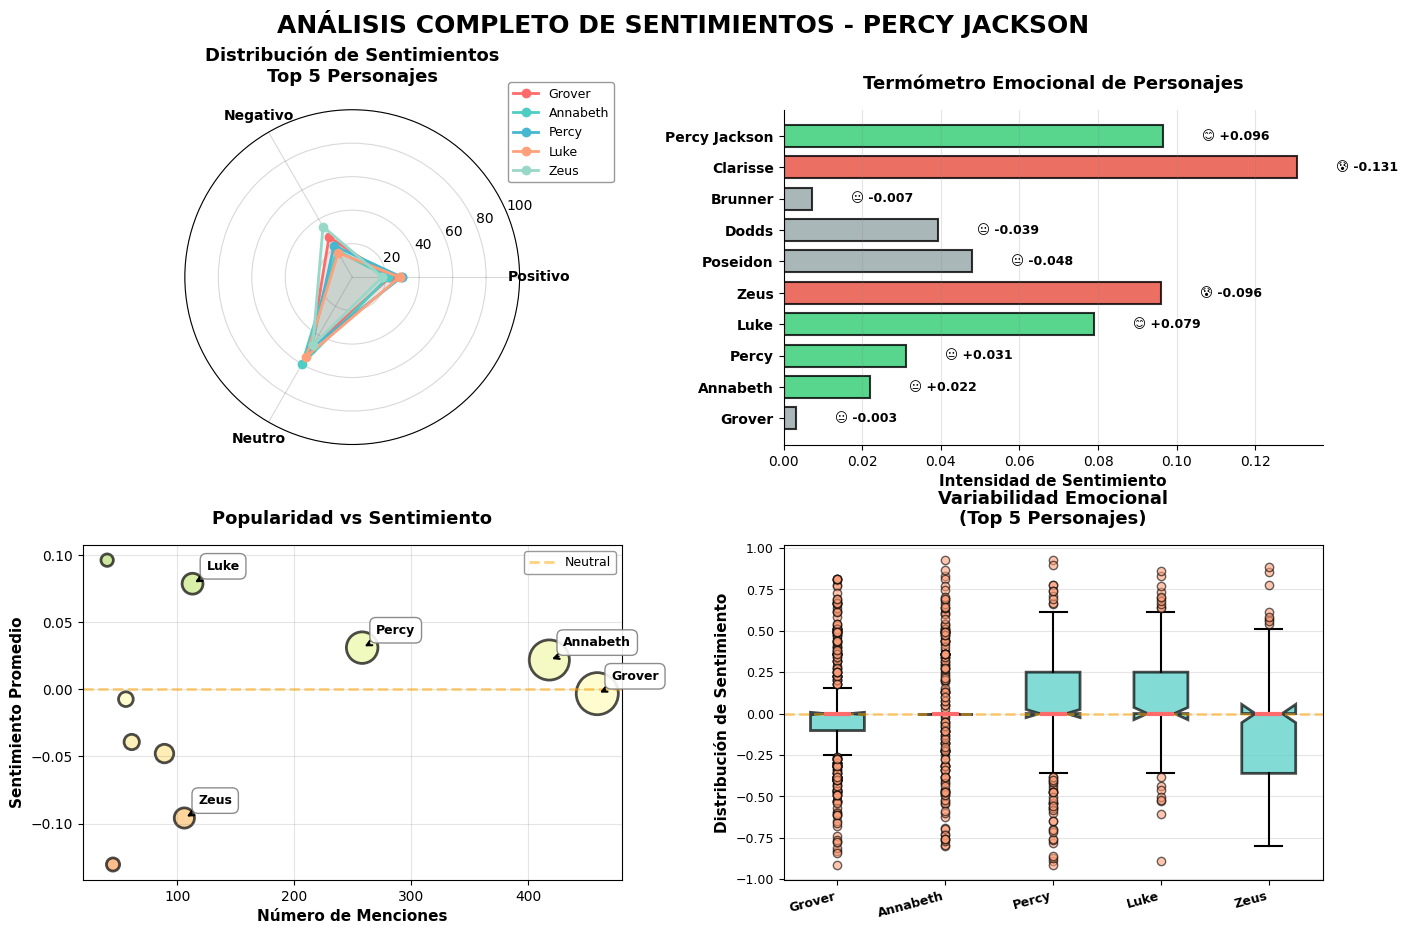


ESTADÍSTICAS CLAVE DEL ANÁLISIS DE SENTIMIENTOS

Personaje más mencionado: Grover (459 veces)
Personaje más positivo: Percy Jackson
Personaje más negativo: Clarisse

Sentimiento general promedio: -0.0095
Rango de sentimientos: [-0.1306, 0.0964]


In [21]:
# Mapa de Emociones de los Personajes
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as path_effects

fig = plt.figure(figsize=(16, 10), facecolor='white')
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# --- Panel 1: Radar Chart de Sentimientos por Personaje ---
ax1 = fig.add_subplot(gs[0, 0], projection='polar')
top_5_chars = df_personajes.head(5)

angles = np.linspace(0, 2 * np.pi, len(top_5_chars), endpoint=False).tolist()
colors_radar = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

for idx, (_, char) in enumerate(top_5_chars.iterrows()):
    values = [char['pct_positivo'], char['pct_negativo'], char['pct_neutro']]
    angle_vals = [0, 2*np.pi/3, 4*np.pi/3]
    ax1.plot(angle_vals + [angle_vals[0]], values + [values[0]], 
             'o-', linewidth=2, color=colors_radar[idx], label=char['personaje'])
    ax1.fill(angle_vals + [angle_vals[0]], values + [values[0]], 
             alpha=0.15, color=colors_radar[idx])

ax1.set_ylim(0, 100)
ax1.set_xticks([0, 2*np.pi/3, 4*np.pi/3])
ax1.set_xticklabels(['Positivo', 'Negativo', 'Neutro'], size=10, color='black', weight='bold')
ax1.set_title('Distribución de Sentimientos\nTop 5 Personajes', 
              size=13, weight='bold', color='black', pad=20)
ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9, facecolor='white', edgecolor='gray')
ax1.grid(color='gray', alpha=0.3)
ax1.set_facecolor('white')
ax1.tick_params(colors='black')

# --- Panel 2: Termómetro de Sentimientos ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('white')

y_pos = np.arange(len(df_personajes))
sentimientos_norm = df_personajes['sentimiento_promedio'].values

# Crear barras horizontales con gradiente de color
for i, (sent, pers) in enumerate(zip(sentimientos_norm, df_personajes['personaje'])):
    color = '#2ecc71' if sent > 0 else ('#e74c3c' if sent < -0.05 else '#95a5a6')
    bar = ax2.barh(i, abs(sent), color=color, alpha=0.8, height=0.7, 
                    edgecolor='black', linewidth=1.5)
    
    # Agregar emojis según sentimiento
    emoji = '😊' if sent > 0.05 else ('😰' if sent < -0.05 else '😐')
    ax2.text(abs(sent) + 0.01, i, f'{emoji} {sent:+.3f}', 
             va='center', fontsize=9, weight='bold', color='black')

ax2.set_yticks(y_pos)
ax2.set_yticklabels(df_personajes['personaje'], fontsize=10, color='black', weight='bold')
ax2.set_xlabel('Intensidad de Sentimiento', fontsize=11, weight='bold', color='black')
ax2.set_title('Termómetro Emocional de Personajes', 
              fontsize=13, weight='bold', color='black', pad=15)
ax2.grid(axis='x', alpha=0.2, color='gray')
ax2.tick_params(colors='black')
ax2.spines['bottom'].set_color('black')
ax2.spines['left'].set_color('black')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- Panel 3: Scatter Plot de Menciones vs Sentimiento ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor('white')

x = df_personajes['menciones'].values
y = df_personajes['sentimiento_promedio'].values
sizes = df_personajes['menciones'].values * 2

scatter = ax3.scatter(x, y, s=sizes, c=y, cmap='RdYlGn', 
                      alpha=0.7, edgecolors='black', linewidth=2,
                      vmin=-0.3, vmax=0.3)

# Etiquetar los top 5 personajes
for i, row in df_personajes.head(5).iterrows():
    ax3.annotate(row['personaje'], 
                 xy=(row['menciones'], row['sentimiento_promedio']),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=9, weight='bold', color='black',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9),
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax3.axhline(y=0, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Neutral')
ax3.set_xlabel('Número de Menciones', fontsize=11, weight='bold', color='black')
ax3.set_ylabel('Sentimiento Promedio', fontsize=11, weight='bold', color='black')
ax3.set_title('Popularidad vs Sentimiento', fontsize=13, weight='bold', color='black', pad=15)
ax3.legend(fontsize=9, facecolor='white', edgecolor='gray', labelcolor='black')
ax3.grid(alpha=0.2, color='gray')
ax3.tick_params(colors='black')
for spine in ax3.spines.values():
    spine.set_color('black')

# --- Panel 4: Diagrama de Cajas Emocionales ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor('white')

# Extraer distribuciones de sentimientos para los top 5 personajes
top_5_names = df_personajes.head(5)['personaje'].tolist()
sentiment_distributions = []

for personaje in top_5_names:
    if personaje in sentimiento_por_personaje:
        sentiment_distributions.append(sentimiento_por_personaje[personaje])
    else:
        sentiment_distributions.append([0])

bp = ax4.boxplot(sentiment_distributions, labels=top_5_names,
                 patch_artist=True, notch=True, 
                 boxprops=dict(facecolor='#4ECDC4', alpha=0.7, linewidth=2),
                 whiskerprops=dict(color='black', linewidth=1.5),
                 capprops=dict(color='black', linewidth=1.5),
                 medianprops=dict(color='#FF6B6B', linewidth=3),
                 flierprops=dict(marker='o', markerfacecolor='#FFA07A', 
                                markersize=6, alpha=0.6))

ax4.axhline(y=0, color='orange', linestyle='--', linewidth=2, alpha=0.5)
ax4.set_ylabel('Distribución de Sentimiento', fontsize=11, weight='bold', color='black')
ax4.set_title('Variabilidad Emocional\n(Top 5 Personajes)', 
              fontsize=13, weight='bold', color='black', pad=15)
ax4.tick_params(colors='black', labelsize=9)
ax4.set_xticklabels(top_5_names, rotation=15, ha='right', color='black', weight='bold')
ax4.grid(axis='y', alpha=0.2, color='gray')
for spine in ax4.spines.values():
    spine.set_color('black')

# Título general
fig.suptitle('ANÁLISIS COMPLETO DE SENTIMIENTOS - PERCY JACKSON', 
             fontsize=18, weight='bold', color='black', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Resumen textual con formato atractivo
print("\n" + "="*80)
print("ESTADÍSTICAS CLAVE DEL ANÁLISIS DE SENTIMIENTOS")
print("="*80)
print(f"\nPersonaje más mencionado: {df_personajes.iloc[0]['personaje']} ({int(df_personajes.iloc[0]['menciones'])} veces)")
print(f"Personaje más positivo: {df_personajes.loc[df_personajes['sentimiento_promedio'].idxmax(), 'personaje']}")
print(f"Personaje más negativo: {df_personajes.loc[df_personajes['sentimiento_promedio'].idxmin(), 'personaje']}")
print(f"\nSentimiento general promedio: {df_personajes['sentimiento_promedio'].mean():.4f}")
print(f"Rango de sentimientos: [{df_personajes['sentimiento_promedio'].min():.4f}, {df_personajes['sentimiento_promedio'].max():.4f}]")
print("="*80)

### 5.6. Análisis de Partes del Discurso (POS Tagging)
En esta sección se calcula la frecuencia de cada parte del discurso (sustantivos, verbos, adjetivos, etc.) utilizando las etiquetas gramaticales generadas por spaCy. Se excluyen signos de puntuación y espacios para enfocarnos únicamente en el contenido lingüístico relevante.

Los resultados se organizan en un DataFrame y se visualizan en un gráfico de barras con las categorías más frecuentes, lo que permite entender mejor la estructura gramatical predominante del texto.

  POS        POS_español  frecuencia
 NOUN         Sustantivo       16103
 VERB              Verbo       15444
 PRON          Pronombre       15327
  ADP        Preposición        9103
  DET       Determinante        8143
  AUX           Auxiliar        6113
  ADJ           Adjetivo        5503
PROPN      Nombre Propio        5466
  ADV           Adverbio        4957
 PART          Partícula        2812
CCONJ  Conj. Coordinante        2797
SCONJ Conj. Subordinante        1889
  NUM             Número         882
 INTJ       Interjección         595
PUNCT              PUNCT          41
    X                  X          10
  SYM                SYM           2


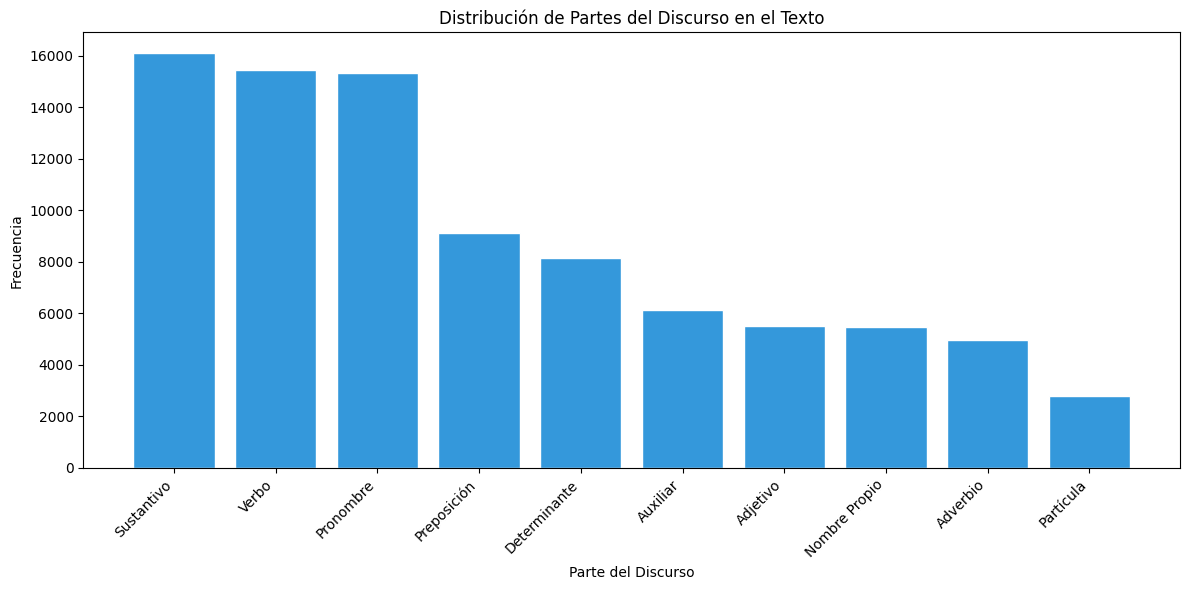

In [22]:
# Extraer distribución de partes del discurso
from collections import Counter
pos_counts = Counter([token.pos_ for token in doc if not token.is_punct and not token.is_space])
df_pos = pd.DataFrame(pos_counts.most_common(), columns=['POS', 'frecuencia'])

# Mapeo de etiquetas POS a español
pos_espanol = {
    'NOUN': 'Sustantivo', 'VERB': 'Verbo', 'ADJ': 'Adjetivo', 
    'ADV': 'Adverbio', 'PROPN': 'Nombre Propio', 'ADP': 'Preposición',
    'DET': 'Determinante', 'PRON': 'Pronombre', 'AUX': 'Auxiliar',
    'CCONJ': 'Conj. Coordinante', 'SCONJ': 'Conj. Subordinante',
    'PART': 'Partícula', 'NUM': 'Número', 'INTJ': 'Interjección'
}
df_pos['POS_español'] = df_pos['POS'].map(pos_espanol).fillna(df_pos['POS'])

print(df_pos[['POS', 'POS_español', 'frecuencia']].to_string(index=False))

# Visualizar
fig, ax = plt.subplots(figsize=(12, 6))
top_pos = df_pos.head(10)
ax.bar(top_pos['POS_español'], top_pos['frecuencia'], color='#3498db', edgecolor='white')
ax.set_xlabel('Parte del Discurso')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Partes del Discurso en el Texto')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 5.7. Análisis de Adjetivos con Carga Emocional

Se extraen los adjetivos del texto utilizando las etiquetas gramaticales de spaCy, excluyendo palabras vacías y términos muy cortos para enfocarse en descripciones significativas. Luego, se calcula la frecuencia de cada adjetivo y se analiza su carga emocional mediante VADER, clasificándolos como positivos, negativos o neutros según su puntaje compuesto. Finalmente, se visualizan los adjetivos positivos y negativos más frecuentes, lo que permite identificar qué tipo de descripciones predominan en la narrativa y cómo contribuyen al tono emocional general del texto.

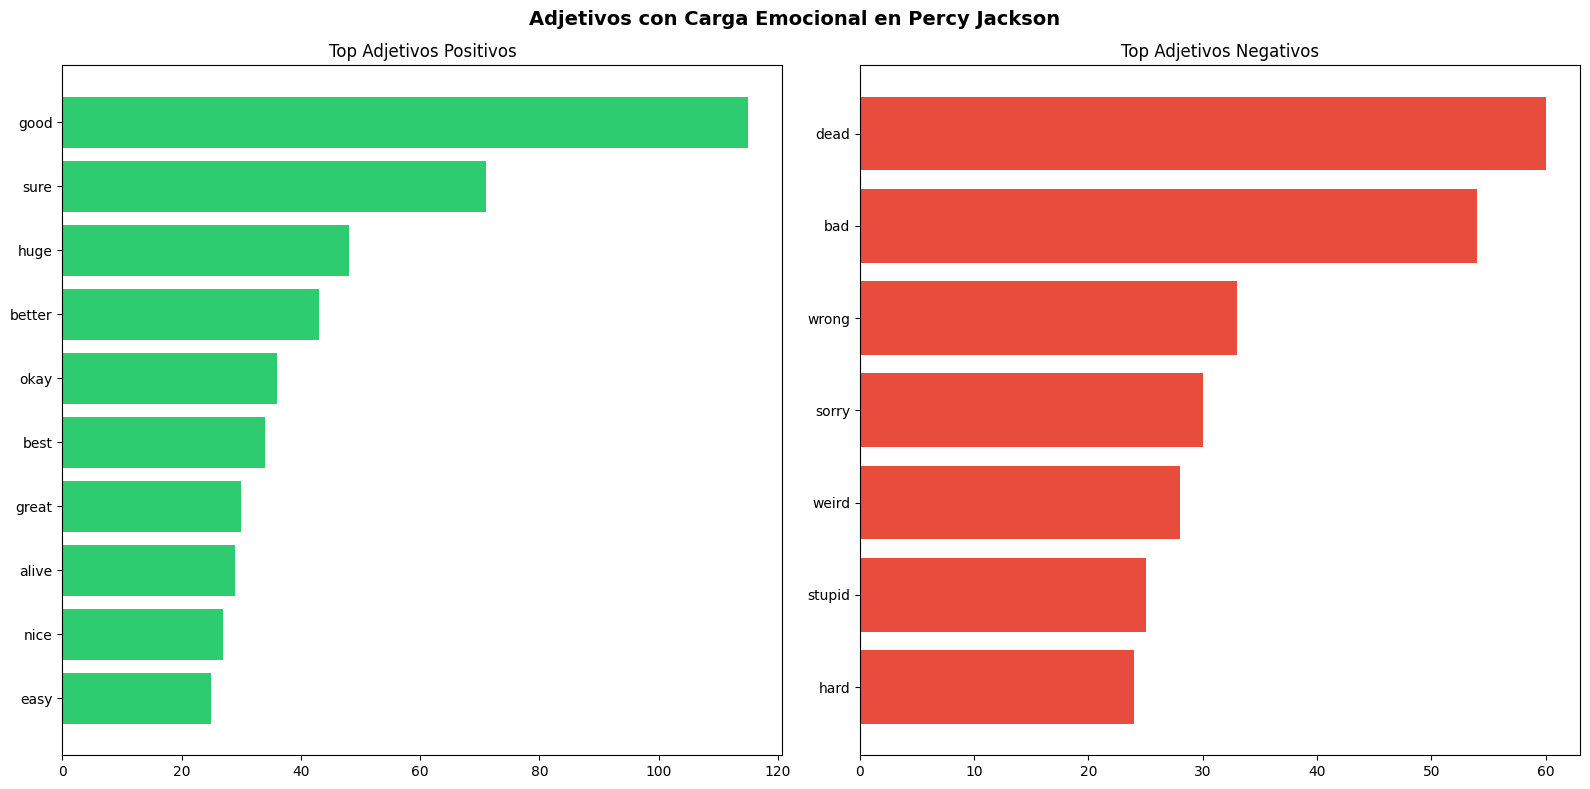

In [23]:
# Extraer todos los adjetivos (excluyendo stopwords)
adjetivos = [token.text.lower() for token in doc 
             if token.pos_ == 'ADJ' and not token.is_stop and len(token.text) > 2]
conteo_adj = Counter(adjetivos)

# Analizar sentimiento de cada adjetivo
datos_adj = []
for adj, freq in conteo_adj.most_common(40):
    score = sid.polarity_scores(adj)
    datos_adj.append({
        'adjetivo': adj,
        'frecuencia': freq,
        'compound': score['compound'],
        'clasificacion': 'Positivo' if score['compound'] > 0.05 
                         else ('Negativo' if score['compound'] < -0.05 else 'Neutro')
    })

df_adj = pd.DataFrame(datos_adj)

# Visualizar adjetivos positivos vs negativos
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
adj_pos = df_adj[df_adj['clasificacion'] == 'Positivo'].head(10)
axes[0].barh(adj_pos['adjetivo'], adj_pos['frecuencia'], color='#2ecc71')
axes[0].set_title('Top Adjetivos Positivos')
axes[0].invert_yaxis()

adj_neg = df_adj[df_adj['clasificacion'] == 'Negativo'].head(10)
axes[1].barh(adj_neg['adjetivo'], adj_neg['frecuencia'], color='#e74c3c')
axes[1].set_title('Top Adjetivos Negativos')
axes[1].invert_yaxis()

plt.suptitle('Adjetivos con Carga Emocional en Percy Jackson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.8. Visualización de Entidades y Estructura Sintáctica

En esta sección se selecciona una oración representativa del texto que contenga múltiples entidades nombradas y se visualiza utilizando displacy, la herramienta gráfica de spaCy. Primero se muestran las entidades detectadas (personas, lugares, organizaciones, etc.) junto con su categoría gramatical, y luego se renderiza tanto el resaltado de entidades como el árbol de dependencias sintácticas. Esta visualización permite comprender cómo spaCy interpreta la estructura lingüística de la oración y cómo se relacionan sus componentes gramaticales dentro del contexto narrativo.

In [24]:
from spacy import displacy

# Seleccionar una oración con múltiples entidades para visualizar
oraciones_lista = list(doc.sents)
oracion_ejemplo = None
for sent in oraciones_lista[50:200]:
    if len(sent.ents) >= 2 and 20 < len(sent.text) < 200:
        oracion_ejemplo = sent
        break

if oracion_ejemplo:
    print(f'Oración: "{oracion_ejemplo.text.strip()}"')
    for ent in oracion_ejemplo.ents:
        print(f"  {ent.text} → {ent.label_} ({spacy.explain(ent.label_)})")
    
    # Renderizar entidades (HTML interactivo en Jupyter)
    displacy.render(oracion_ejemplo, style="ent", jupyter=True)
    
    # Renderizar árbol de dependencias
    displacy.render(oracion_ejemplo, style="dep", jupyter=True, 
                    options={"compact": True, "distance": 90})


Oración: "But Mr. Brunner, our Latin teacher, was leading this trip, so I had hopes."
  Brunner → PERSON (People, including fictional)
  Latin → NORP (Nationalities or religious or political groups)


### 5.9. Impacto de la Negación en el Sentimiento

En esta sección se analizan las oraciones del texto para identificar cuáles contienen estructuras de negación (detectadas mediante la etiqueta sintáctica neg de spaCy) y cuáles no. Posteriormente, se calcula el puntaje de sentimiento (compound) de cada grupo utilizando VADER y se comparan sus promedios. Finalmente, se visualiza la distribución de sentimientos mediante histogramas, lo que permite evaluar cómo la presencia de negaciones influye en la polaridad emocional del texto y si tiende a intensificar o modificar el tono general de las oraciones.

Oraciones CON negación:    1,140
  → Sentimiento promedio:  0.0085

Oraciones SIN negación:    7,542
  → Sentimiento promedio:  0.0008


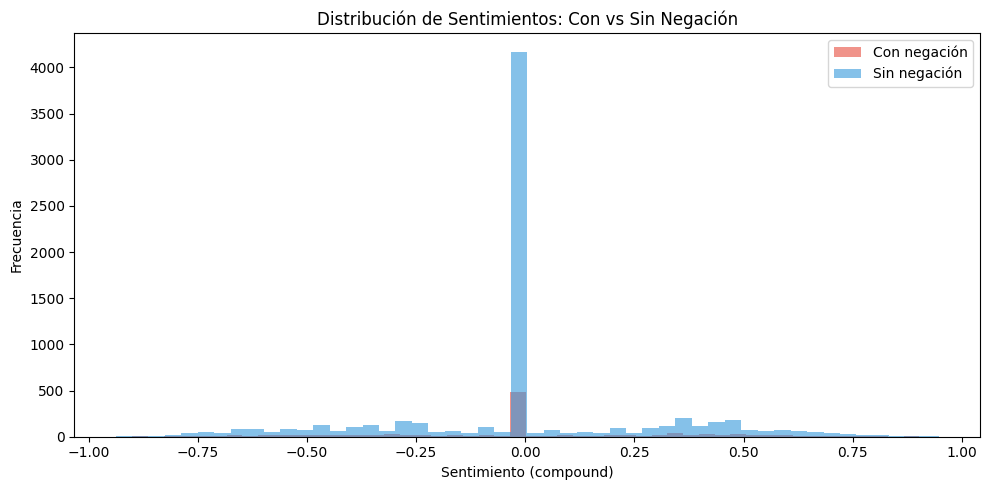

In [25]:
# Identificar oraciones con y sin negaciones
oraciones_con_negacion = []
oraciones_sin_negacion = []

for sent in doc.sents:
    texto = sent.text.strip()
    if len(texto) < 10:
        continue
    tiene_negacion = any(token.dep_ == 'neg' for token in sent)
    score = sid.polarity_scores(texto)['compound']
    
    if tiene_negacion:
        oraciones_con_negacion.append(score)
    else:
        oraciones_sin_negacion.append(score)

print(f"Oraciones CON negación:    {len(oraciones_con_negacion):,}")
print(f"  → Sentimiento promedio:  {np.mean(oraciones_con_negacion):.4f}")
print(f"\nOraciones SIN negación:    {len(oraciones_sin_negacion):,}")
print(f"  → Sentimiento promedio:  {np.mean(oraciones_sin_negacion):.4f}")

# Visualizar comparación
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(oraciones_con_negacion, bins=50, alpha=0.6, label='Con negación', color='#e74c3c')
ax.hist(oraciones_sin_negacion, bins=50, alpha=0.6, label='Sin negación', color='#3498db')
ax.set_xlabel('Sentimiento (compound)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Sentimientos: Con vs Sin Negación')
ax.legend()
plt.tight_layout()
plt.show()


### 5.10. Clasificación Temática y Sentimiento por Similitud Semántica

En esta sección se definen temas de referencia (como batalla, amistad, familia, miedo y aventura) representados mediante conjuntos de palabras clave. Luego, para cada oración del texto, se calcula su similitud semántica con cada tema utilizando el modelo de spaCy y se asigna el tema más cercano.

Posteriormente, se analiza el sentimiento de cada oración con VADER y se construye un resumen agregando la cantidad de oraciones asociadas a cada tema y su sentimiento promedio. Esto permite identificar cuáles son los temas predominantes en el texto y cómo se comporta emocionalmente cada uno dentro de la narrativa.

In [26]:
# Definir temas de referencia para comparar
temas_referencia = {
    'Batalla/Combate': nlp("fighting battle sword monster attack danger"),
    'Amistad': nlp("friend friendship trust help together loyal"),
    'Familia': nlp("mother father family home parent child"),
    'Miedo/Peligro': nlp("scared afraid danger fear terror horror"),
    'Aventura/Viaje': nlp("journey travel quest adventure road trip")
}

resultados_tematicos = []
for i, sent in enumerate(doc.sents):
    if i >= 500:
        break
    texto = sent.text.strip()
    if len(texto) < 20:
        continue
    
    sent_doc = nlp(texto)
    mejor_tema, mejor_sim = max(
        ((tema, sent_doc.similarity(ref)) for tema, ref in temas_referencia.items()),
        key=lambda x: x[1])
    
    score = sid.polarity_scores(texto)['compound']
    resultados_tematicos.append({'tema': mejor_tema, 'similitud': mejor_sim, 'sentimiento': score})

df_temas = pd.DataFrame(resultados_tematicos)
resumen_temas = df_temas.groupby('tema').agg(
    cantidad=('sentimiento', 'count'),
    sentimiento_promedio=('sentimiento', 'mean')
).sort_values('cantidad', ascending=False)

print(resumen_temas.to_string(float_format='%.4f'))


                 cantidad  sentimiento_promedio
tema                                           
Amistad               141               -0.0025
Familia               113               -0.0148
Miedo/Peligro          99               -0.0306
Batalla/Combate        60                0.0203
Aventura/Viaje         38               -0.0201


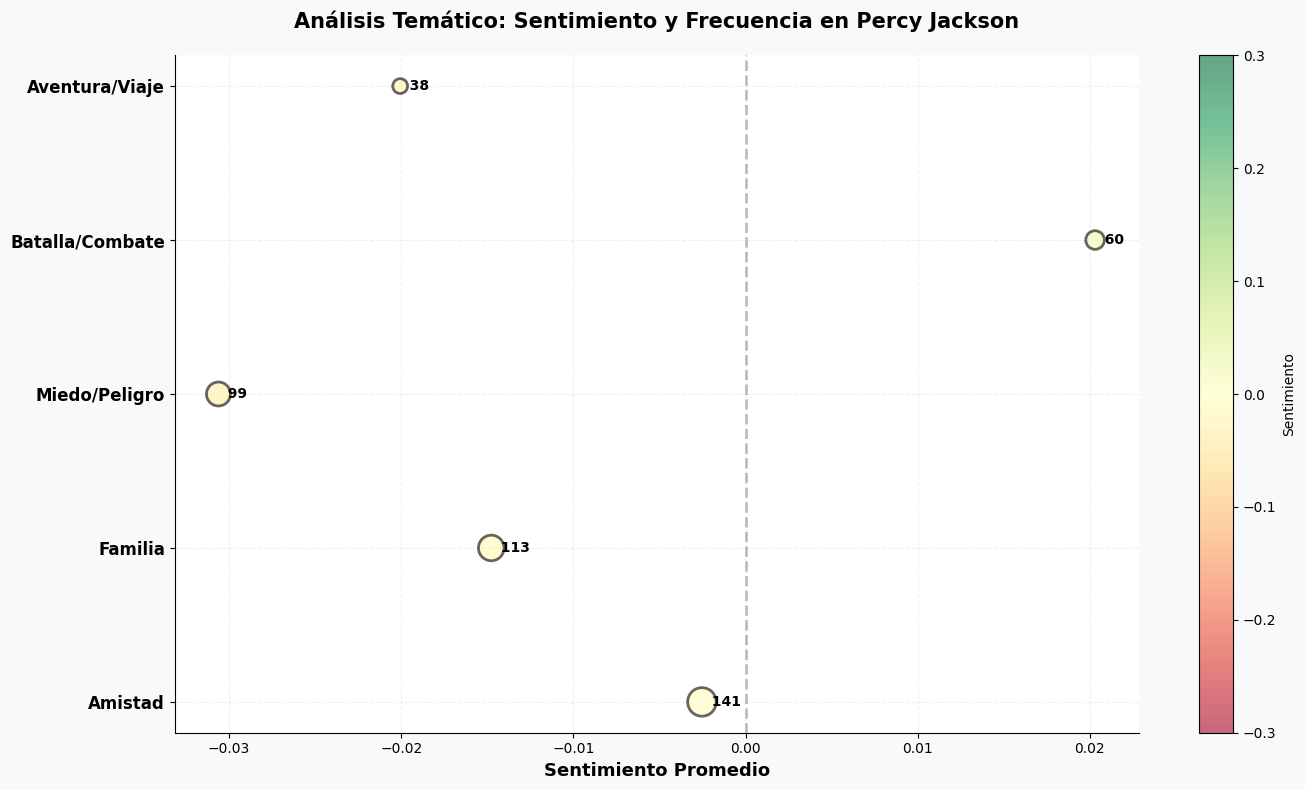

In [27]:
# Visualización de temas y sentimientos
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 8), facecolor='#f8f9fa')

# Preparar datos
temas = resumen_temas.index.tolist()
cantidades = resumen_temas['cantidad'].values
sentimientos = resumen_temas['sentimiento_promedio'].values

# Crear colores basados en el sentimiento (escala de rojo a verde)
colors = []
for sent in sentimientos:
    if sent > 0.05:  # Positivo
        color = plt.cm.Greens(min(sent, 1))
    elif sent < -0.05:  # Negativo
        color = plt.cm.Reds(abs(min(sent, -1)))
    else:  # Neutro
        color = '#d3d3d3'
    colors.append(color)

# Crear scatter plot con burbujas de diferentes tamaños
scatter = ax.scatter(sentimientos, range(len(temas)), 
                     s=cantidades*3,  # Tamaño proporcional a cantidad
                     c=sentimientos, cmap='RdYlGn', 
                     alpha=0.6, edgecolors='black', linewidth=2,
                     vmin=-0.3, vmax=0.3)

# Ajustar ejes
ax.set_yticks(range(len(temas)))
ax.set_yticklabels(temas, fontsize=12, fontweight='bold')
ax.set_xlabel('Sentimiento Promedio', fontsize=13, fontweight='bold')
ax.set_title('Análisis Temático: Sentimiento y Frecuencia en Percy Jackson', 
             fontsize=15, fontweight='bold', pad=20)

# Agregar línea vertical en 0 para sentimiento neutral
ax.axvline(x=0, color='gray', linestyle='--', linewidth=2, alpha=0.5, label='Neutral')

# Agregar colorbar
cbar = plt.colorbar(scatter, ax=ax, label='Sentimiento')

# Agregar etiquetas de cantidad dentro/cerca de las burbujas
for i, (sent, cant) in enumerate(zip(sentimientos, cantidades)):
    ax.text(sent, i, f'  {int(cant)}', va='center', fontsize=10, fontweight='bold')

# Estilo mejorado
ax.grid(True, alpha=0.2, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()



Al observar el gráfico, se puede notar que la historia gira principalmente en torno a la amistad y la familia. Estos son los temas que aparecen con mayor frecuencia (burbujas mas grandes), lo que confirma que, más allá de la acción y la mitología, el núcleo emocional del libro está en las relaciones entre los personajes.

El análisis de sentimientos muestra que Aventura es el tema con el puntaje promedio más alto, lo que indica que los momentos relacionados con viajes, exploración y acción generan emociones más positivas dentro de la narrativa. En contraste, Amistad presenta el sentimiento promedio más bajo, lo que sugiere que las relaciones entre los personajes están marcadas por conflictos, tensiones o desafíos emocionales más complejos.

---
## 6. Arco Narrativo del Libro

Al procesar las oraciones en orden y calcular el sentimiento promedio por ventana deslizante,
podemos reconstruir el **arco emocional de la narrativa**: ver cómo suben y bajan las tensiones
a lo largo del libro. Aquí también usamos `doc.sents` de spaCy para mantener el orden original.

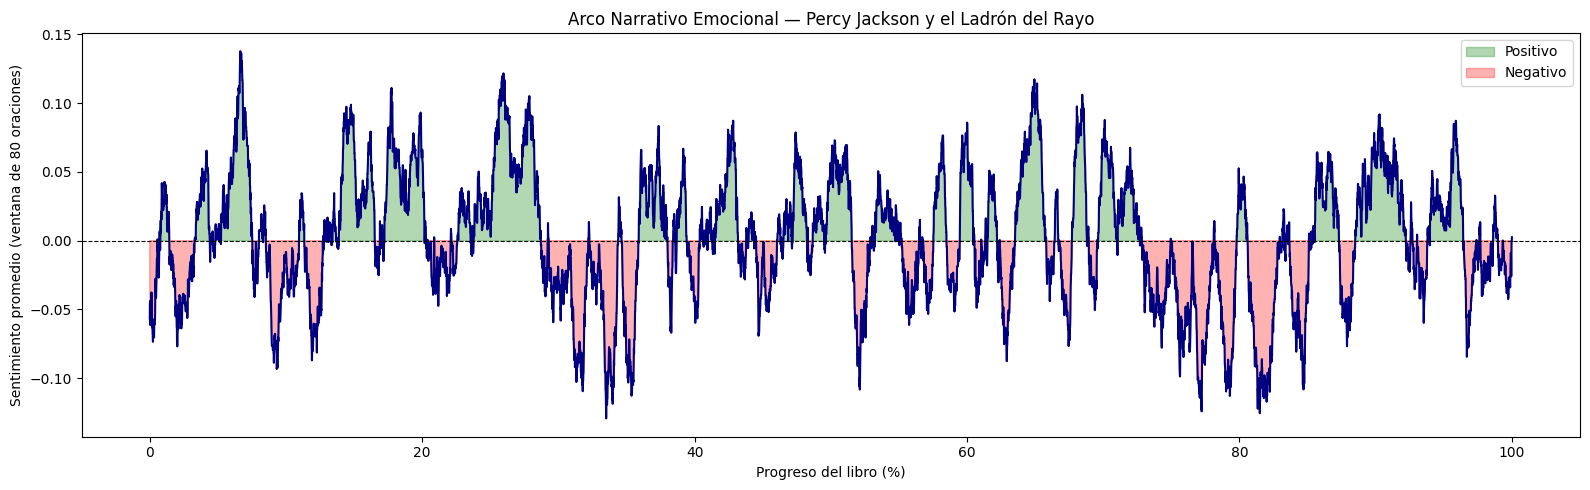

Momento más positivo del libro: 6.6% del texto (score: 0.138)
Momento más negativo del libro: 33.5% del texto (score: -0.129)


In [28]:
import numpy as np

# ─────────────────────────────────────────────────────────────────
# Usamos los datos ya calculados en df (que mantiene el orden de doc.sents)
# Aplicamos una ventana deslizante (rolling window) para suavizar la curva
# y revelar el arco emocional general del libro
# ─────────────────────────────────────────────────────────────────
WINDOW = 80  # tamaño de la ventana: promedio de 80 oraciones consecutivas

compound_series = df['compound'].values
rolling_avg = np.convolve(compound_series,
                          np.ones(WINDOW)/WINDOW,
                          mode='valid')

# Normalizar posición a porcentaje del libro
x_axis = np.linspace(0, 100, len(rolling_avg))

plt.figure(figsize=(16, 5))
plt.fill_between(x_axis, rolling_avg, 0,
                 where=(rolling_avg >= 0), color='green', alpha=0.3, label='Positivo')
plt.fill_between(x_axis, rolling_avg, 0,
                 where=(rolling_avg < 0),  color='red',   alpha=0.3, label='Negativo')
plt.plot(x_axis, rolling_avg, color='navy', linewidth=1.5)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Progreso del libro (%)')
plt.ylabel('Sentimiento promedio (ventana de 80 oraciones)')
plt.title('Arco Narrativo Emocional — Percy Jackson y el Ladrón del Rayo')
plt.legend()
plt.tight_layout()
plt.show()

# Punto más positivo y más negativo
idx_max = np.argmax(rolling_avg)
idx_min = np.argmin(rolling_avg)
print(f"Momento más positivo del libro: {x_axis[idx_max]:.1f}% del texto (score: {rolling_avg[idx_max]:.3f})")
print(f"Momento más negativo del libro: {x_axis[idx_min]:.1f}% del texto (score: {rolling_avg[idx_min]:.3f})")

---
## 7. Nube de Palabras por Sentimiento

Usamos el lematizador de spaCy (`token.lemma_`) para normalizar las palabras y filtramos stopwords con `token.is_stop`.
Luego generamos nubes de palabras separadas para oraciones **positivas** y **negativas**, lo que nos permite ver visualmente qué vocabulario domina cada polaridad.

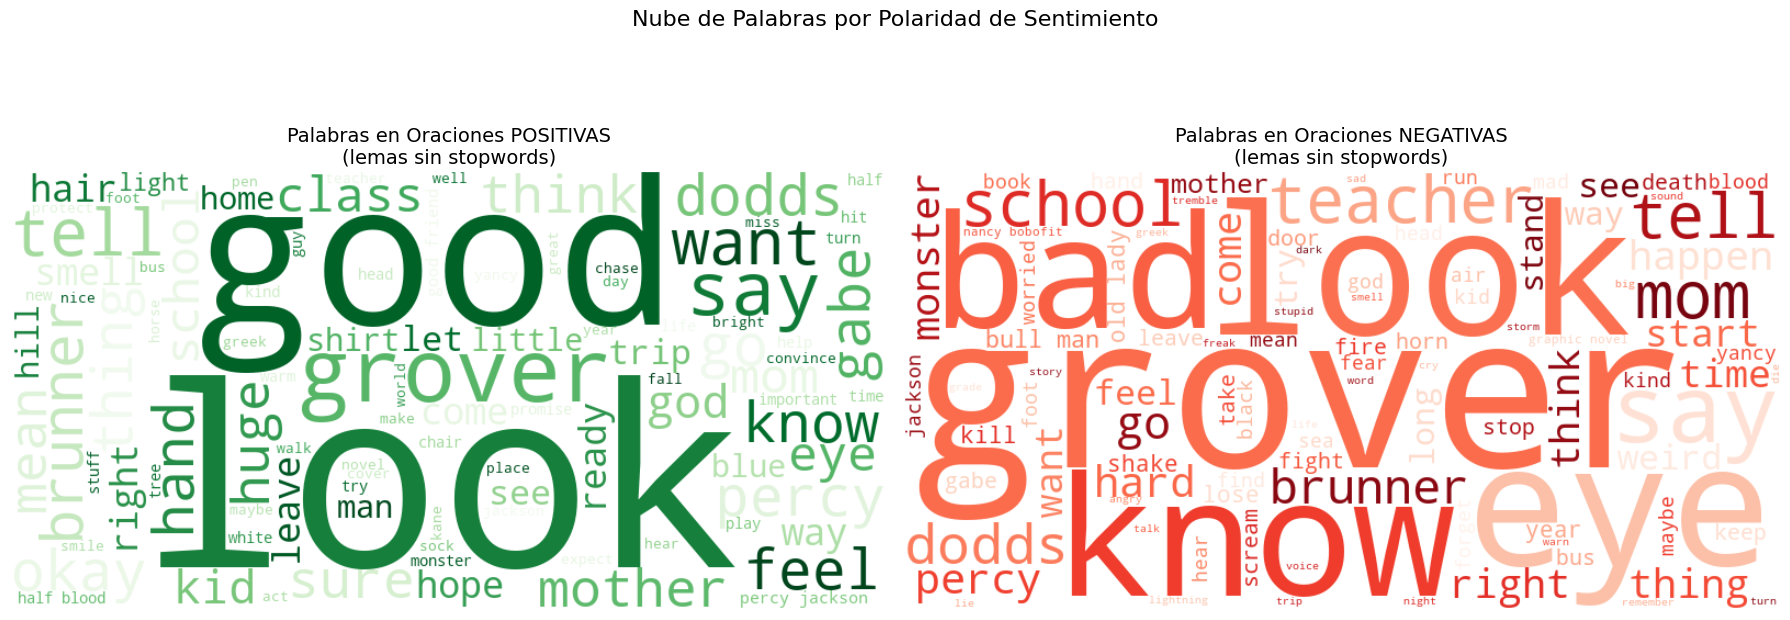

In [29]:
try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'wordcloud', '-q'])
    from wordcloud import WordCloud

def get_lemmatized_words(sentences_list):
    """
    Recibe una lista de oraciones, las procesa con spaCy y devuelve
    una cadena de lemas limpios (sin stopwords ni puntuación).
    token.lemma_  → forma base/raíz de la palabra
    token.is_stop → True si es una palabra muy común (the, a, is...)
    token.is_punct → True si es signo de puntuación
    """
    words = []
    for sent in sentences_list:
        sent_doc = nlp(sent)
        for token in sent_doc:
            if token.is_alpha and not token.is_stop and len(token.text) > 2:
                words.append(token.lemma_.lower())
    return ' '.join(words)

# Separar oraciones positivas y negativas del DataFrame
pos_sentences = df[df['label'] == 'pos']['sentence'].tolist()
neg_sentences = df[df['label'] == 'neg']['sentence'].tolist()

pos_words = get_lemmatized_words(pos_sentences[:300])  # muestra de 300 oraciones
neg_words = get_lemmatized_words(neg_sentences[:300])

# Generar y mostrar las nubes
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(pos_words)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Palabras en Oraciones POSITIVAS\n(lemas sin stopwords)', fontsize=14)

wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate(neg_words)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Palabras en Oraciones NEGATIVAS\n(lemas sin stopwords)', fontsize=14)

plt.suptitle('Nube de Palabras por Polaridad de Sentimiento', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()